#Predictive Modeling & Decision Analytics for Sustainable Agriculture

### Project Context
This project focuses on leveraging Machine Learning to predict crop yields based on soil bacterial composition. In this final phase, we transition from data exploration to **predictive modeling** and **policy-making simulations**.

# Objectives
* **Model Benchmarking:** Experiment with how different types of regression models perform.
* **Evaluation Metrics:** Utilize MAE and R² to assess predictive accuracy.
* **Brainstorming:** How the government decides which model (or if to use a model) to implement in their policy-making decisions.
* **Decision Analytics:** Use evaluation metrics and decision analytics in order to determine how much your model would increase crop yield compared to not using a machine learning model at all in policy decisions.

In [1]:
#@title ###Setup notebook.

# Sample metadata
!wget -q --show-progress "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Sustainable%20Farming/sample_metadata.tsv"

# bacteria counts lognorm
!wget -q --show-progress "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Sustainable%20Farming/bacteria_counts_lognorm.csv"

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error

metadata = pd.read_table('sample_metadata.tsv')
metadata.index = ['farm_%i' % i for i in range(len(metadata))]

bacteria_counts_lognorm = pd.read_csv('bacteria_counts_lognorm.csv', index_col=0)
print("Setup Successful.")

sample_metadata.tsv 100%[===================>]  62.82K  --.-KB/s    in 0.001s  
bacteria_counts_log 100%[===================>]   7.10M  --.-KB/s    in 0.08s   
Setup Successful.


# Experimenting with Different Models

To predict crop yield from bacterial composition of soil, we chose a regression model because crop yield is a continuous numerical value, not a discrete category. We evaluated different regression architectures to identify the optimal model for this dataset.


1. Decision Tree Regressor

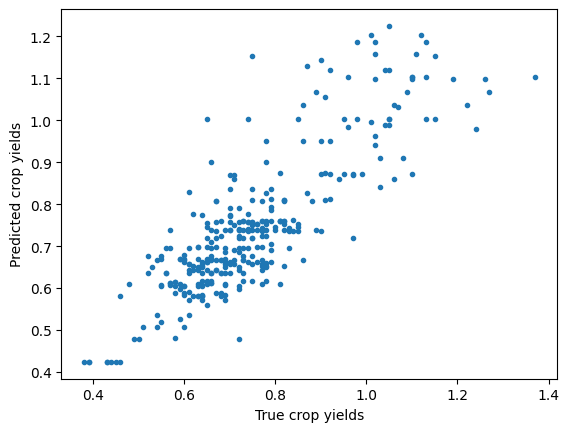

In [2]:
# Defining X and y data
X = bacteria_counts_lognorm
y = metadata['crop_yield']

# Splitting the dataset into training and testing sets
X_train_dtr, X_test_dtr, y_train_dtr, y_test_dtr = train_test_split(X, y)

# Model initialization with optimized depth and leaf node constraints
decision_tree_regressor = DecisionTreeRegressor(max_depth=100, max_leaf_nodes=200)

# Training the model on the training dataset
decision_tree_regressor.fit(X_train_dtr, y_train_dtr)

# Predictions
preds_dtr = decision_tree_regressor.predict(X_test_dtr)

# VISUALIZATION: Plot predictions against the true crop yields of the test data
plt.plot(y_test_dtr, preds_dtr, '.')
plt.xlabel('True crop yields')
plt.ylabel('Predicted crop yields')
plt.show()

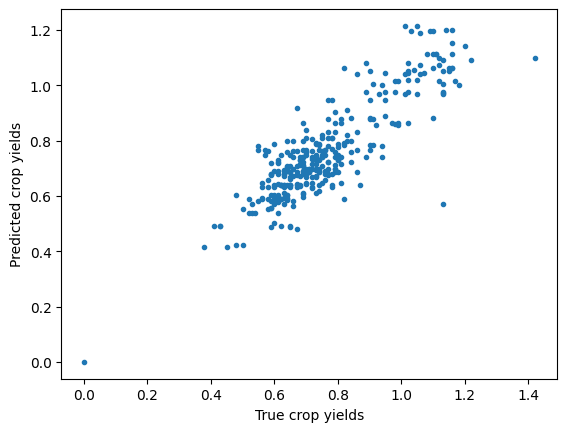

In [3]:
X = bacteria_counts_lognorm
y = metadata['crop_yield']

# Split into testing and training
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = DecisionTreeRegressor(max_depth=100, max_leaf_nodes=200)

model.fit(X_train, y_train)

# Making predictions on our test data
preds = model.predict(X_test)

# Plot
plt.plot(y_test, preds, '.')
plt.xlabel('True crop yields')
plt.ylabel('Predicted crop yields')
plt.show()

2. K-Nearest Neighbors (KNN) Regressor

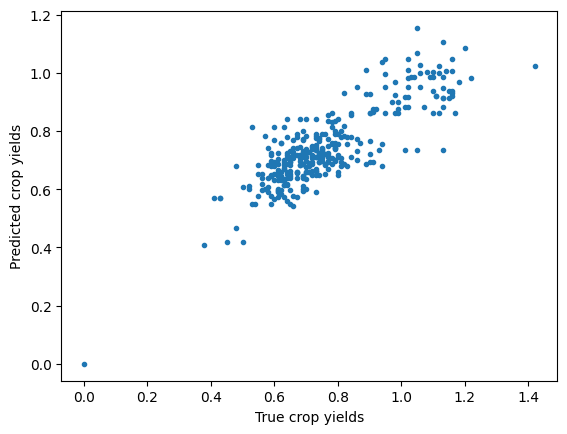

In [4]:
# nearest neighbor
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train
knn_model.fit(X_train, y_train)
# Make predictions on our test data
predictions = knn_model.predict(X_test)

# Plot predictions against the true crop yields of the test data
plt.plot(y_test, predictions, ".")
plt.xlabel('True crop yields')
plt.ylabel('Predicted crop yields')
plt.show()

3. Neural Network (MLP Regressor)

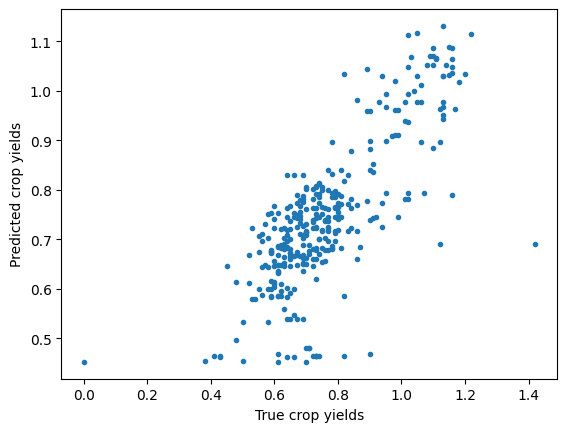

In [5]:
# Neural Network
nnet = MLPRegressor(hidden_layer_sizes=(2,5), random_state=1, max_iter=1000)

# Train the model
nnet.fit(X_train, y_train)

# predictions
predictions = nnet.predict(X_test)

# Plotting the predictions against the true crop yields of the test data
plt.plot(y_test, predictions, ".")
plt.xlabel('True crop yields')
plt.ylabel('Predicted crop yields')
plt.show()

# Policy Making

<img src = "https://upload.wikimedia.org/wikipedia/commons/e/ee/Korea_President_Park_US_Congress_20130507_03.jpg" width=500/>

If we were policy-makers trying to figure out where to allow farming, how would we decide which model to rely on? When selecting a model for agricultural policy, the priority is a balance between accuracy, interpretability, and efficiency. While predictive power is essential, a model must be transparent enough to justify government resource allocation.


As far as i see, often policy-makers (and people in the medical field) prefer decision trees, linear regression, and other simple models over more sophisticted models such as neural networks. This is because interpretability is key; stakeholders need to understand the underlying logic of a decision to ensure it is fair, accountable, and legally sound.

For a deeper dive into model complexity and public accountability, there isan analysis by the **Brookings Institution**:
[The Tensions Between Explainable AI and Good Public Policy](https://www.brookings.edu/articles/the-tensions-between-explainable-ai-and-good-public-policy/)

The successful implementation of AI in public policy hinges on navigating three critical challenges: mitigating algorithmic bias, ensuring ethical governance, and balancing the inherent trade-off between model performance and explainability.

# Evaluating Regression Models


How to use some simple evaluation metrics to assess which model has better performance?

There are three popular metrics that usually reported to measure regressor performance.

### 1. Coefficient of determination ($R^2$).

Since R is the correlation between the test predictions and the true test y-values, $R^2$ is a measure of how well the variabilty in the test predictions are explained by the variability in the true values. You can compute $R^2$ using the ```r2_score``` function. Correlation between data points can be described by the image below. Note that you might remember $R^2$ for linear regression. Well $R^2$ can be used to evaluate the performance of any regression model, since regression models are predicting continuous variables.

<img src="https://i.stack.imgur.com/CLfKl.jpg"/>

Although it may appear that $R^2$ can only lie within the range [0,1], this is only true when your regression is somewhat explanatory. Only when a horizontal line explains the data better than your regression model will $R^2 < 0$. Below is an exagerated example of when $R^2$ is negative where a straight horizontal line is better than the regression.

<img src="https://i.stack.imgur.com/XPHqc.png"/>

There is also a very negative $R^2$ value if the linear regression plot is forced to have an intercept of 0.[.](https://i0.wp.com/www.fairlynerdy.com/wp-content/uploads/2017/01/Negative-R-Squared.png?w=690)

####**Should a good model have a high or low $R^2$?**


####**We computed the $R^2$ for our model using the ```r2_score``` function.**

In [6]:
R2 = r2_score(y_test, predictions)
print('R2=', R2)

R2= 0.5834655556189716


**Which model performed the best?**

## **Additional Evaluation Metrics**

### 2. Mean Absolute Error (`MAE`)
The mean absolute error is the average error between our test predictions and your true values of y.  We can compute the Mean Absolute Error using the ```sklearn``` ```mean_absolute_error``` function. **Should a good model have a big or small MAE?**

####**We computed the MAE for your model using the ```mean_absolute_error``` function.**

In [7]:
MAE = mean_absolute_error(y_test, predictions)
print('MAE=', MAE)

MAE= 0.08381040990442683


### 3. Relative Squared Error (RSE)
The relative squared error (RSE) is the error in the model predictions relative to the predictions we would have gotten if we used a very "simple model" (this "simple model" just being the average of all of the test data values). A good model has a RSE close to zero, and a bad model has an RSE close to or higher than 1.

[function documentation to compute averages](https://numpy.org/doc/stable/reference/generated/numpy.mean.html)

### **Which model produced the best $R^2$, MAE, and RSE? Did the same model perform the best in all metrics?**

# Decision Analytics

Ultimately, coefficient of determination, MAE, and RSE are not our main point. What we really care about is how much a model will improve the world's farming practices. In our case, we would like to know how much using a particular model will increase crop yield compared to using other models or no models at all.

***Decision analytics*** is a field dedicated to using mathematics, computer simulations, and machine learning in order to quantitatively make decisons. Decision analytics and machine learning often go hand-in-hand!  

Using the results of our machine learning model, we are going to write a small computer simulation to see how much our model will improve crop yield compared to not using a model at all.

<img src = "https://www.environmentalscience.org/wp-content/uploads/2018/09/Env-Law-Scale-300x300.jpg"/>

## Identifying Fields to Farm On

Imagine this scenario: In trying to keep up with the dietary needs of their people, a country's government plans on choosing 10 new plots of land to subsidize for farming. Let's pretend they are using our model (trained on our *training* data) to decide which plots of land to convert to farms (choosing between those in our *test* data).

Before going to the exercise, **Which 10 farms should our model choose?**

In [8]:
metadata

,crop_yield,sample_type,country,timestamp
farm_0,0.68,barley soil sample,GAZ:Australia,2011-3-26
farm_1,1.00,barley soil sample,GAZ:Australia,2011-11-22
farm_2,0.87,barley soil sample,GAZ:Australia,2011-6-10
farm_3,0.68,barley soil sample,GAZ:Australia,2011-11-3
farm_4,0.67,barley soil sample,GAZ:Australia,2011-3-26
...,...,...,...,...
farm_1339,0.74,barley soil sample,GAZ:Australia,2011-3-9
farm_1340,0.77,barley soil sample,GAZ:Australia,2011-9-25
farm_1341,0.69,barley soil sample,GAZ:Australia,2011-2-13
farm_1342,0.44,barley soil sample,GAZ:Australia,2011-1-2


#### **Finding the names of the top 10 farms that our model predicted will have the highest crop yield**

To do this, we're first going to need our predictions. Then, we'll create a new pandas dataframe with the predictions and their corresponding farm numbers.

In [9]:
crop_yield_test_predictions = knn_model.predict(X_test)

yield_predictions_dataframe = pd.DataFrame(data={'farm':X_test.index, 'crop_yield':crop_yield_test_predictions})
yield_predictions_dataframe.head(10)

,farm,crop_yield
0,farm_798,0.550
1,farm_127,0.830
2,farm_950,0.632
3,farm_971,0.698
4,farm_791,0.862
5,farm_559,0.862
6,farm_384,0.712
7,farm_22,0.856
8,farm_656,0.638
9,farm_98,0.758


Now that we have our predictions dataframe, we can sort it to find the top 10 farms.

In [10]:
# We sorted our predictions dataframe (in variable called yield_predictions_dataframe) by crop yield, and looked at the top 10 farms.
sorted_dataframe = yield_predictions_dataframe.sort_values(by='crop_yield', ascending=False)

# Taking the top 10 farms using .head().
top_farms_dataframe = sorted_dataframe.head(10)
farm_names=top_farms_dataframe['farm']
print("According to our model, the top 10 best plots are:", farm_names.to_list())
top_farms_dataframe

According to our model, the top 10 best plots are: ['farm_394', 'farm_844', 'farm_993', 'farm_429', 'farm_1122', 'farm_450', 'farm_565', 'farm_1031', 'farm_552', 'farm_52']


,farm,crop_yield
78,farm_394,1.154
220,farm_844,1.106
23,farm_993,1.086
90,farm_429,1.068
98,farm_1122,1.048
144,farm_450,1.048
218,farm_565,1.046
255,farm_1031,1.038
15,farm_552,1.026
202,farm_52,1.024


####**If the government had gone with this model's suggestions, what would have been the total crop yield of the 10 farms?**


In [11]:
# This extracts the true crop yields from the 10 farms the model suggested crop_yields_top_10_predictions is thus an array of crop yields with length 10.
crop_yields_top_10_predictions = top_farms_dataframe['crop_yield']

total_crop_yield_using_model = crop_yields_top_10_predictions.sum()
print("total crop yield using model suggestions: ", total_crop_yield_using_model)

total crop yield using model suggestions:  10.643999999999998


## Does our model perform better than random chance?

**What if the government didn't use our model, and just did a lottery instead? What would total crop yield be then? How would we simulate that?**

<img src ="https://live.staticflickr.com/600/23203939895_7a81a512b8_b.jpg" width=400 />

#### **The code below is to simulate the government picking plots to farm on via lottery, rather than using our model.**


In [12]:
#Changing this to pick a different set of randomly chosen
np.random.seed(42)

#crop_yields_10_random_picks should then be an array of crop yields with length 10.
crop_yields_10_random_picks = np.random.choice(y_test, size=10, replace=False)

# computing the total crop yield from all 10 randomly chosen farms combined
total_crop_yield_using_lottery = crop_yields_10_random_picks.sum()
print("Total crop yield using random picks: ", total_crop_yield_using_lottery)

Total crop yield using random picks:  7.479999999999999


**Which performed better -- our model's farms or the randomly chosen set of farms?**

#### When we change the ```random.seed``` in the code above to simulate a different set of randomly chosen farms.

We probably want to simulate this process of the government picking  random farms many times in order to understand what range of values we might get for total crop yield.

#### **Computing the total crop yield for 100 simulations of the government choosing 10 random fields to farm on:**


In [13]:
# randomly picking 10 farms/crop yields from our test (we did 100 iterations)
total_crop_yield_using_lottery_list = np.array([])
for simulation in range(100):

  crop_yields_10_random_picks = np.random.choice(y_test, size=10, replace=False)
  total_crop_yield_using_lottery = crop_yields_10_random_picks.sum()

  #Filling in the value we want to append to our list of total crop yields:
  total_crop_yield_using_lottery_list = np.append(total_crop_yield_using_lottery_list, total_crop_yield_using_lottery)

print('lottery crop yields: ', total_crop_yield_using_lottery_list)

lottery crop yields:  [7.95 8.22 7.31 7.14 7.69 7.36 7.71 7.92 8.04 7.89 7.34 7.63 8.34 7.75
 8.19 7.79 6.47 7.66 7.23 7.65 8.13 7.41 7.43 7.14 7.61 7.18 8.28 8.04
 7.48 8.02 6.16 8.17 7.05 7.93 7.63 8.55 8.65 7.27 6.37 7.36 6.84 7.68
 8.32 8.36 7.16 8.09 7.67 7.67 8.04 7.33 7.32 7.5  6.5  7.32 6.81 7.27
 8.05 7.94 7.08 7.68 7.51 7.39 7.93 7.38 8.26 7.16 7.41 7.71 8.   6.75
 7.15 7.57 8.08 7.56 8.38 7.86 7.89 6.89 8.   7.71 7.58 7.69 7.86 7.58
 7.18 7.89 7.34 7.27 7.81 7.09 7.7  7.84 8.14 7.55 7.9  7.5  7.29 7.76
 7.53 7.66]


#### **What would be the average crop yield if the government chose farms based on lottery?**


In [14]:
avg_total_crop_yield_from_lottery = np.mean(total_crop_yield_using_lottery_list)
print("average crop yield using lottery system:", avg_total_crop_yield_from_lottery)

average crop yield using lottery system: 7.605199999999999


Dotted line represents total crop yield if using model to select farms.


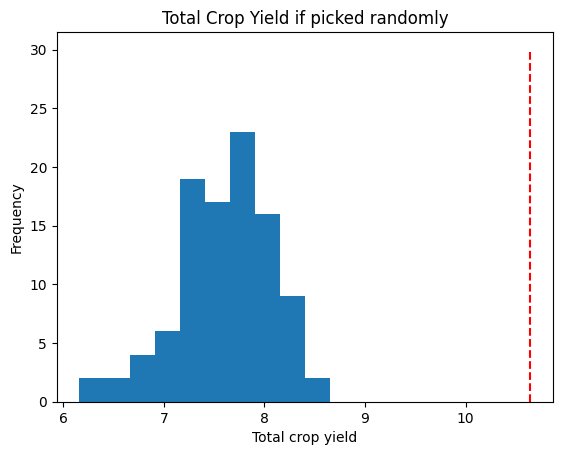

In [15]:
plt.hist(total_crop_yield_using_lottery_list)
plt.vlines(total_crop_yield_using_model, ymin=0, ymax=30, color='r', linestyle='dashed')
plt.xlabel('Total crop yield')
plt.ylabel('Frequency')
plt.title('Total Crop Yield if picked randomly')
print('Dotted line represents total crop yield if using model to select farms.')

## **3-sentence memo to the legislator.**


**Based on all of the metrics so far, should the government our model into sustainable farming policy?**

<img src = "https://spia.princeton.edu/sites/default/files/blog/images/Policy%20Memo%20-%20main%20photo.jpg" width=300 />



In [16]:
#@title Dear legislator, { form-width: "100%" }
_ = "Our data-driven model demonstrates that predicting crop yields based on soil bacterial composition significantly increases agricultural efficiency compared to traditional random allocation methods. By integrating this AI-assisted approach into sustainable farming policies, we can optimize resource use and ensure long-term food security while minimizing environmental impact. I strongly recommend implementing this predictive model to transition from intuitive land management to evidence-based agricultural legislation." #@param {type:"string"}
_ = ''